In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:/Users/polin/Downloads/archive(1)/Salary_Data.csv")
x=(df["YearsExperience"].values)
y=(df["Salary"].values)


In [3]:
x

array([ 1.1,  1.3,  1.5,  2. ,  2.2,  2.9,  3. ,  3.2,  3.2,  3.7,  3.9,
        4. ,  4. ,  4.1,  4.5,  4.9,  5.1,  5.3,  5.9,  6. ,  6.8,  7.1,
        7.9,  8.2,  8.7,  9. ,  9.5,  9.6, 10.3, 10.5])

In [4]:
y

array([ 39343,  46205,  37731,  43525,  39891,  56642,  60150,  54445,
        64445,  57189,  63218,  55794,  56957,  57081,  61111,  67938,
        66029,  83088,  81363,  93940,  91738,  98273, 101302, 113812,
       109431, 105582, 116969, 112635, 122391, 121872])

Text(0.5, 1.0, 'Experience vs Salary')

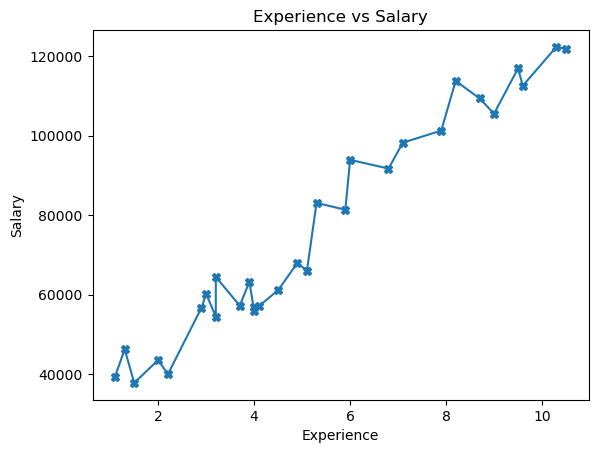

In [5]:
plt.plot(x,y,marker="X")
plt.xlabel("Experience")
plt.ylabel("Salary")
plt.title("Experience vs Salary")

In [6]:
x = np.array(x)
y = np.array(y)

In [7]:
def mean(x):
    return np.sum(x)/len(x)
    

In [8]:
def variance(x):
    mean_value = mean(x)
    return np.sum((x-mean_value)**2)/len(x)
    

In [9]:
def norm(x):
    mean_value = mean(x)
    variance_value = variance(x)
    return (x-mean_value)/np.sqrt(variance_value)

In [10]:
x_norm = norm(x)

In [11]:
x_norm

array([-1.51005294, -1.43837321, -1.36669348, -1.18749416, -1.11581443,
       -0.86493538, -0.82909552, -0.75741579, -0.75741579, -0.57821647,
       -0.50653674, -0.47069688, -0.47069688, -0.43485702, -0.29149756,
       -0.1481381 , -0.07645838, -0.00477865,  0.21026054,  0.2461004 ,
        0.53281931,  0.6403389 ,  0.92705781,  1.03457741,  1.21377673,
        1.32129632,  1.50049564,  1.5363355 ,  1.78721455,  1.85889428])

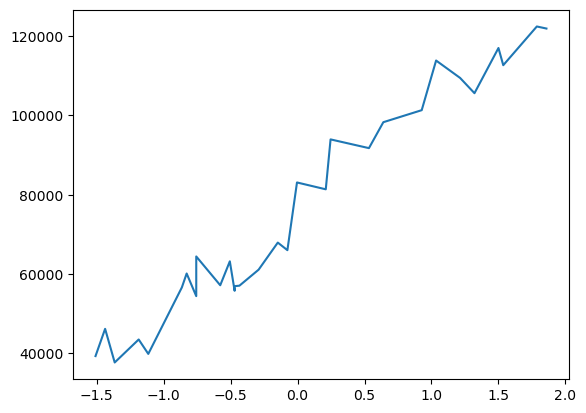

In [12]:
plt.plot(x_norm,y)

In [13]:
import random

In [14]:
class Lrm:
    def __init__(self,lr = 0.1,max_iter = 2000,threshold = 1e-6):
        self.lr = lr
        self.max_iter = max_iter
        self.threshold = threshold
        self.weight = random.uniform(-1,1)
        self.bias = random.uniform(-1,1)
    def predict(self,x):
        return self.weight * x + self.bias
    def fit(self,x,y):
        n = len(x)
        loss_history = []
        y_pred = self.predict(x)
        errors = y-y_pred
        prev_loss = (1/(2*n))*np.sum(errors**2)
        loss_history.append(prev_loss)
        for i in range(self.max_iter):
            w_grad = (1/n)*np.sum(errors*x)
            b_grad = (1/n)*np.sum(errors)
            self.weight += self.lr * w_grad
            self.bias += self.lr * b_grad
            y_pred = self.predict(x)
            errors = y-y_pred
            curr_loss = (1/(2*n))*np.sum(errors**2)
            if np.abs(curr_loss - prev_loss) < self.threshold:
                break
            prev_loss = curr_loss
            loss_history.append(curr_loss)
        return loss_history
    def plot(self,x,y):
        y_pred = self.predict(x)
        plt.plot(x,y)
        plt.plot(x,y_pred)
            

In [15]:
model=Lrm()

In [16]:
loss_history = model.fit(x_norm,y)

In [17]:
loss_history

[np.float64(3251526218.3878417),
 np.float64(2636706977.307769),
 np.float64(2138703392.0329096),
 np.float64(1735320487.9602728),
 np.float64(1408580335.661438),
 np.float64(1143920812.2993815),
 np.float64(929546598.3761159),
 np.float64(755903485.0982704),
 np.float64(615252563.343216),
 np.float64(501325316.7216216),
 np.float64(409044246.95813006),
 np.float64(334296580.4497021),
 np.float64(273750970.5778754),
 np.float64(224709026.58169582),
 np.float64(184985051.94479033),
 np.float64(152808632.48889682),
 np.float64(126745732.72962314),
 np.float64(105634783.92461148),
 np.float64(88534915.39255197),
 np.float64(74684021.88158378),
 np.float64(63464798.13769959),
 np.float64(54377226.90515337),
 np.float64(47016294.206790976),
 np.float64(41053938.72111737),
 np.float64(36224430.77772177),
 np.float64(32312529.343571287),
 np.float64(29143889.18190943),
 np.float64(26577290.650963347),
 np.float64(24498345.840897013),
 np.float64(22814400.54474327),
 np.float64(21450404.854858

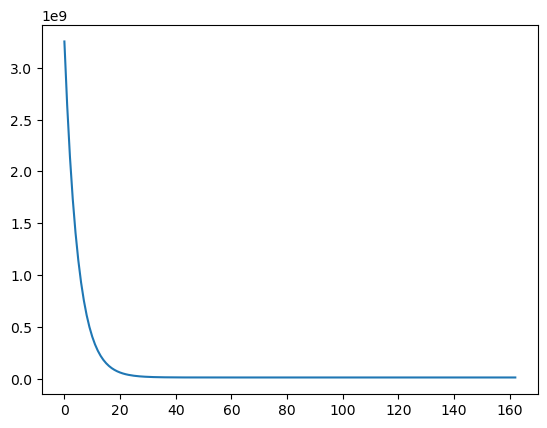

In [18]:
plt.plot(loss_history)

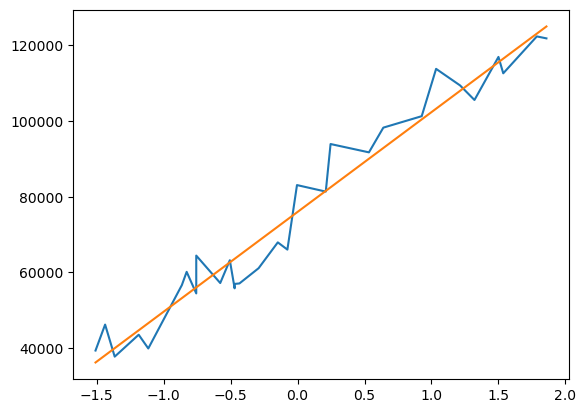

In [19]:
model.plot(x_norm,y)

In [20]:
test_x =[10,15,5,12,23,22,11]
mean_value=mean(x)
variance_value=variance(x)
test_x_norm = (test_x-mean_value)/np.sqrt(variance_value)
predict = model.predict(test_x_norm)
predict

array([120291.81922751, 167541.62919065,  73042.00926436, 139191.74321276,
       243141.32513168, 233691.36313905, 129741.78122013])